# Projeto realizado no curso da Asimov Academy

Projeto Final de limpeza e tratamento de dados com Pandas  com os DataSets disponibilizados pela plataforma Kaggle, onde foi explorado dados de :
Obesidade por país no período de 1975 á 2016;
PIB per capita no período de 1901 á 2011.

1. [Obesity among adults by country, 1975-2016](https://www.kaggle.com/amanarora/obesity-among-adults-by-country-19752016/)
2. [GDP Per Person (1901-2011)](https://www.kaggle.com/divyansh22/gdp-per-person-19012011?select=GDP.csv)

Tais conjuntos de dados são públicos foram publicados no Kaggle.

In [ ]:
import pandas as pd
import numpy as np

## Perguntas - Obesity among adults by country, 1975-2016

In [ ]:
df_obesity = pd.read_csv("obesity_cleaned.csv", index_col=0)
df_obesity

,Country,Year,Obesity (%),Sex
0,Afghanistan,1975,0.5 [0.2-1.1],Both sexes
1,Afghanistan,1975,0.2 [0.0-0.6],Male
2,Afghanistan,1975,0.8 [0.2-2.0],Female
3,Afghanistan,1976,0.5 [0.2-1.1],Both sexes
4,Afghanistan,1976,0.2 [0.0-0.7],Male
...,...,...,...,...
24565,Zimbabwe,2015,4.5 [2.4-7.6],Male
24566,Zimbabwe,2015,24.8 [18.9-31.3],Female
24567,Zimbabwe,2016,15.5 [12.0-19.2],Both sexes
24568,Zimbabwe,2016,4.7 [2.5-8.0],Male


- Limpando os dados do DataFrame, criando uma coluna de nome 'Obesity' que conterá os valores de obesidade. Transformando em float as colunas que porventura foram importadas como string.

In [ ]:
df_obesity.dtypes
df_obesity.columns

Index(['Country', 'Year', 'Obesity (%)', 'Sex'], dtype='object')

In [ ]:
df_obesity['Obesity'] = df_obesity['Obesity (%)'].str.extract(r'^([\d\.]+)').astype(float)
df_obesity['Year'] = df_obesity['Year'].apply(lambda x: float(x))
df_obesity

,Country,Year,Obesity (%),Sex,Obesity
0,Afghanistan,1975.0,0.5 [0.2-1.1],Both sexes,0.5
1,Afghanistan,1975.0,0.2 [0.0-0.6],Male,0.2
2,Afghanistan,1975.0,0.8 [0.2-2.0],Female,0.8
3,Afghanistan,1976.0,0.5 [0.2-1.1],Both sexes,0.5
4,Afghanistan,1976.0,0.2 [0.0-0.7],Male,0.2
...,...,...,...,...,...
24565,Zimbabwe,2015.0,4.5 [2.4-7.6],Male,4.5
24566,Zimbabwe,2015.0,24.8 [18.9-31.3],Female,24.8
24567,Zimbabwe,2016.0,15.5 [12.0-19.2],Both sexes,15.5
24568,Zimbabwe,2016.0,4.7 [2.5-8.0],Male,4.7


Percentual médio de obesidade por sexo no mundo no ano de 2015

In [ ]:
df_2015 = df_obesity[df_obesity['Year'] == 2015]
df_2015.groupby('Sex')['Obesity'].mean()

,Obesity
Sex,
Both sexes,19.508377
Female,22.899476
Male,15.980628


Quais são os 5 países com a maior e a menor taxa de aumento nos índices de obesidade no período observado?

In [ ]:
df_start = df_obesity[df_obesity['Year'] == 1975]
df_end = df_obesity[df_obesity['Year'] == 2016]

df_start.set_index('Country', inplace = True)
df_end.set_index('Country', inplace = True)


In [ ]:
df_ob_diff = df_end[df_end['Sex'] ==  'Both sexes']['Obesity'] - df_start[df_start['Sex'] == 'Both sexes']['Obesity']
df_ob_diff.sort_values(ascending= True).dropna().head(5)

,Obesity
Country,
Viet Nam,2.0
Singapore,3.1
Japan,3.3
Bangladesh,3.4
Timor-Leste,3.6


In [ ]:
df_ob_diff.sort_values(ascending= True).dropna().tail(5)

,Obesity
Country,
Cook Islands,27.9
Tonga,28.3
Kiribati,30.1
Niue,31.1
Tuvalu,33.7


Quais os países com maiores e menores níveis percetuais de obesidade em 2015?

In [ ]:
df_15_maior = df_2015.groupby('Country')['Obesity'].max()
df_15_maior.sort_values(ascending=True).dropna().head(5)

,Obesity
Country,
Viet Nam,2.4
Cambodia,4.6
Timor-Leste,4.6
Japan,4.6
Bangladesh,4.7


In [ ]:
df_15_maior.sort_values(ascending=True).dropna().tail(5)[::-1]

,Obesity
Country,
Nauru,63.1
Cook Islands,58.8
Palau,58.4
Marshall Islands,56.9
Tuvalu,55.6


In [ ]:
df_15_dict = df_15_maior.to_dict()
df_15_dict
for key, values in df_15_dict.items():
  if values < 5:
    print("{} {}".format(key, values))

Bangladesh 4.7
Cambodia 4.6
India 4.8
Japan 4.6
Republic of Korea 4.7
Timor-Leste 4.6
Viet Nam 2.4


Qual a diferença média percentual de obesidade entre sexos ao longo dos anos para o Brasil?

In [ ]:
df_mean_male = df_obesity[(df_obesity['Country'] == 'Brazil') & (df_obesity['Sex'] == 'Male')]['Obesity']
df_mean_female = df_obesity[(df_obesity['Country'] == 'Brazil') & (df_obesity['Sex'] == 'Female')]['Obesity']
print(df_mean_female - df_mean_male)

2899   NaN
2900   NaN
2902   NaN
2903   NaN
2905   NaN
        ..
3017   NaN
3019   NaN
3020   NaN
3022   NaN
3023   NaN
Name: Obesity, Length: 84, dtype: float64


<Axes: xlabel='Year'>

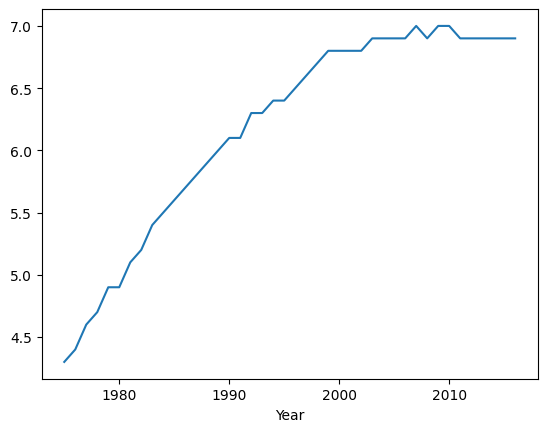

In [ ]:
df_brazil = df_obesity[df_obesity['Country'] == 'Brazil']
df_brazil.set_index('Year', inplace = True)
(df_brazil[df_brazil['Sex'] == 'Female']['Obesity'] - df_brazil[df_brazil['Sex'] == 'Male']['Obesity'])
(df_brazil[df_brazil['Sex'] == 'Female']['Obesity'] - df_brazil[df_brazil['Sex'] == 'Male']['Obesity']).plot()

Plotando um gráfico mostrando a evolução da obesidade para ambos sexos no mundo?

<Axes: xlabel='Year'>

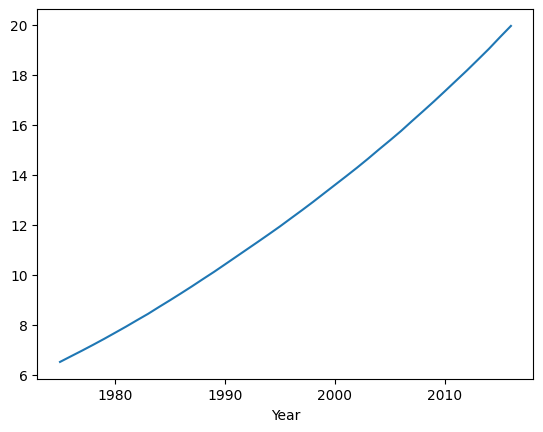

In [ ]:
df_both = df_obesity[df_obesity['Sex'] == 'Both sexes']
df_both.groupby('Year')['Obesity'].mean().plot()

##GDP Per Person (1901-2011)

In [ ]:
df_gdp = pd.read_csv("gdp.csv", decimal=".")
df_gdp.columns

Index(['Country', 'Region', 'Year', ' GDP_pp '], dtype='object')

Limpando o conjunto de dados, convertendo strings em datas ou float, quando necessário.

In [ ]:
df_gdp = df_gdp.rename(columns = {' GDP_pp ' : 'gdp_pp'})
df_gdp['gdp_pp'] = df_gdp['gdp_pp'].str.strip()
df_gdp['gdp_pp'] = df_gdp['gdp_pp'].str.replace(',', '', regex=False)
df_gdp["gdp_pp"] = df_gdp['gdp_pp'].apply(lambda x: float(x))

In [ ]:
df_gdp['Year'] = pd.to_datetime(df_gdp['Year'])

Qual o primeiro valor registrado de cada país?

In [ ]:
df_gdp.groupby('Country')[['Year', 'gdp_pp']].min()

,Year,gdp_pp
Country,,
Afghanistan,1901-01-01,595.04
Albania,1901-01-01,1062.01
Algeria,1901-01-01,1807.76
Andorra,1901-01-01,3352.50
Angola,1901-01-01,525.76
...,...,...
Venezuela,1901-01-01,766.21
Vietnam,1901-01-01,572.96
"Yemen, Rep.",1901-01-01,729.39


In [ ]:
df_gdp.groupby('Country')['Year'].min().value_counts()

df_gdp.groupby('Country')['Year'].min()[df_gdp.groupby('Country')['Year'].min() == '1991']

,Year
Country,
Kosovo,1991-01-01


Quais as regiões com maiores crescimentos de PIB per capita no século passado.

In [ ]:
df_gdp_final = df_gdp[df_gdp['Year'].apply(lambda x: x.year) == 1996]
df_gdp_inicio = df_gdp[df_gdp['Year'].apply(lambda x: x.year) == 1901]
((df_gdp_final.groupby('Region')['gdp_pp'].mean() / df_gdp_inicio.groupby('Region')['gdp_pp'].mean() - 1) * 100).sort_values(ascending= False)

,gdp_pp
Region,
"Middle East, North Africa, and Greater Arabia",857.215950
Asia,711.761516
Europe,594.046167
North America,589.760175
Central America and the Caribbean,406.426789
Australia and Oceania,396.075383
South America,312.123735
Sub-Saharan Africa,248.633780


In [ ]:
df_gdp[df_gdp['Country'] == 'Brazil']['Year']
## ou
df_gdp[df_gdp['Year'].apply(lambda x : x.year) < 2000].max()

,0
Country,Zimbabwe
Region,Sub-Saharan Africa
Year,1996-01-01 00:00:00
gdp_pp,118681.3


Preecheendo os anos ausentes em cada país com uma estimativa, baseada na diferença entre o próximo registro e o anterior.

In [ ]:
import numpy as np

In [ ]:
arr_year = np.arange(df_gdp['Year'].apply(lambda x: x.year).min(), df_gdp['Year'].apply(lambda x: x.year).max())
df_all_years = pd.DataFrame(arr_year, columns= ['Year'])
df_all_years.index = df_all_years['Year']

df_years_off = ~df_all_years['Year'].isin(df_gdp['Year'].apply(lambda x: x.year))
df_years_off = df_all_years.loc[df_years_off].index
df_years_off


Index([1902, 1903, 1904, 1905, 1907, 1908, 1909, 1910, 1912, 1913, 1914, 1915,
       1917, 1918, 1919, 1920, 1922, 1923, 1924, 1925, 1927, 1928, 1929, 1930,
       1932, 1933, 1934, 1935, 1937, 1938, 1939, 1940, 1942, 1943, 1944, 1945,
       1947, 1948, 1949, 1950, 1952, 1953, 1954, 1955, 1957, 1958, 1959, 1960,
       1962, 1963, 1964, 1965, 1967, 1968, 1969, 1970, 1972, 1973, 1974, 1975,
       1977, 1978, 1979, 1980, 1982, 1983, 1984, 1985, 1987, 1988, 1989, 1990,
       1992, 1993, 1994, 1995, 1997, 1998, 1999, 2000, 2002, 2003, 2004, 2005,
       2007, 2008, 2009, 2010],
      dtype='int64', name='Year')

In [ ]:
df_gdp = df_gdp.sort_values(['Country', 'Year'])
df_gdp['Year'] = df_gdp['Year'].apply(lambda x: int(x.year))

In [ ]:
df_gdp['delta_gdp'] = df_gdp['gdp_pp'] - df_gdp['gdp_pp'].shift(1)
df_gdp['delta_year'] = df_gdp['Year'] - df_gdp['Year'].shift(1)
df_gdp['gdp_year'] = (df_gdp['delta_gdp'] / df_gdp['delta_year']).shift(-1)
df_gdp

,Country,Region,Year,gdp_pp,delta_gdp,delta_year,gdp_year
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1901,613.99,NaN,NaN,2.010
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1906,624.04,10.05,5.0,2.042
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",1911,634.25,10.21,5.0,2.606
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",1916,647.28,13.03,5.0,3.024
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",1921,662.40,15.12,5.0,3.094
...,...,...,...,...,...,...,...
4414,Zimbabwe,Sub-Saharan Africa,1991,782.09,39.79,5.0,-0.118
4415,Zimbabwe,Sub-Saharan Africa,1996,781.50,-0.59,5.0,-12.308
4416,Zimbabwe,Sub-Saharan Africa,2001,719.96,-61.54,5.0,-39.958
4417,Zimbabwe,Sub-Saharan Africa,2006,520.17,-199.79,5.0,1.232


In [ ]:
df_gdp['next year'] = df_gdp['Year'].shift(-1)
del df_gdp['delta_gdp'], df_gdp['delta_year']

In [ ]:
df_new_data = pd.DataFrame()

for idx, row in df_gdp.iterrows():
  if row['Year'] == 2011:
    continue
  years_to_add = df_years_off[(df_years_off < row['next year']) & (df_years_off > row['Year'])]

  for new_year in years_to_add:
    add_row = row.copy()
    add_row['gdp_pp'] = (new_year - add_row['Year']) * add_row['gdp_year'] + add_row['gdp_pp']
    add_row['Year'] = new_year
    add_row['Kind'] = 'Estimated'
    df_new_data = pd.concat([df_new_data, add_row.to_frame().transpose()])

In [ ]:
df_gdp = pd.concat([df_gdp, df_new_data])
df_gdp.sort_values(['Country', 'Year'], inplace = True)
df_gdp['Kind'].fillna('real', inplace= True)
df_gdp.index = df_gdp['Year']
df_gdp

/tmp/ipython-input-4076268346.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_gdp['Kind'].fillna('real', inplace= True)


,Country,Region,Year,gdp_pp,gdp_year,next year,Kind
Year,,,,,,,
1901,Afghanistan,"Middle East, North Africa, and Greater Arabia",1901,613.99,2.01,1906.0,real
1902,Afghanistan,"Middle East, North Africa, and Greater Arabia",1902,616.0,2.01,1906.0,Estimated
1902,Afghanistan,"Middle East, North Africa, and Greater Arabia",1902,616.0,2.01,1906.0,Estimated
1902,Afghanistan,"Middle East, North Africa, and Greater Arabia",1902,616.0,2.01,1906.0,Estimated
1902,Afghanistan,"Middle East, North Africa, and Greater Arabia",1902,616.0,2.01,1906.0,Estimated
...,...,...,...,...,...,...,...
2010,Zimbabwe,Sub-Saharan Africa,2010,525.098,1.232,2011.0,Estimated
2010,Zimbabwe,Sub-Saharan Africa,2010,525.098,1.232,2011.0,Estimated
2010,Zimbabwe,Sub-Saharan Africa,2010,525.098,1.232,2011.0,Estimated


In [ ]:
import matplotlib.pyplot as plt

Plotando o gráfico de dispersão (scatter plot) mostrando a evolução do PIB per capita do Brasil ao longo dos anos, comparando valores reais e estimados.

<Axes: xlabel='Year', ylabel='gdp_pp'>

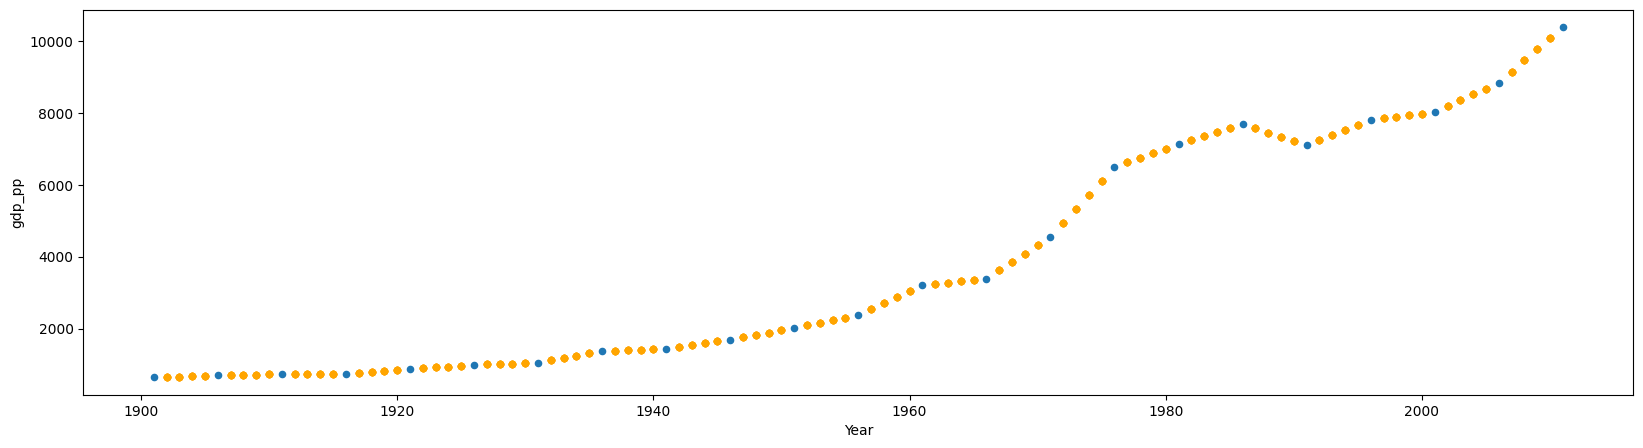

In [ ]:
fig, ax = plt.subplots(figsize = (20, 5))

country = 'Brazil'
df_gdp[(df_gdp['Kind'] == 'real') & (df_gdp['Country'] == country)].plot(kind = 'scatter', y = 'gdp_pp', x= 'Year', ax = ax)
df_gdp[(df_gdp['Kind'] == 'Estimated') & (df_gdp['Country'] == country)].plot(kind = 'scatter', y = 'gdp_pp', x= 'Year', ax = ax, color = 'orange')

Criando um mapa interativo com a biblioteca plotly do permitindo a visualização do gdp mundo ao longo dos anos

In [ ]:
import plotly.express as px

In [ ]:
df = px.data.gapminder()
dict_iso_alpha = df.set_index('country').to_dict()['iso_alpha']
dict_num = {j: i for i, j in enumerate(df_gdp['Country'].unique())}

df_gdp['iso_alpha'] = df_gdp['Country'].map(dict_iso_alpha)
df_gdp['iso_num'] = df_gdp['Country'].map(dict_num)

fig = px.choropleth(df_gdp[df_gdp['Kind'] == 'real'].reset_index(drop=True), locations='iso_alpha', color='gdp_pp', hover_name='Country', animation_frame='Year')
fig.update_layout(height = 600)
fig.show()

Analisando se há uma relação entre níveis de obesidade e gdp per capita?

In [ ]:
## Criando uma nova coluna em df_obesity com os valores (country) e (year) juntos e segmentados com uma "-"
df_obesity['country-year'] = df_obesity['Country'] + "-" + df_obesity.reset_index()['Year'].apply(lambda x: str(int(x))).values
## Criando uma dicionário com o indice(chave) sendo a coluna country-year e o seu valor sendo o índice de obesidade referente a coluna
dict_obesity_year = df_obesity.set_index('country-year').to_dict()['Obesity']


In [ ]:
## Criando uma nova coluna em df_gdp com os valores (country) e (year) juntos e segmentados com uma "-"
df_gdp['country-year'] = df_gdp['Country'] + '-' + df_gdp['Year'].apply(lambda x: str(int(x))).values
## Criando uma nova coluna Obesity em df_gdp e atribuindo a ela a coluna country-year com a função de dict_obesity_year
df_gdp['Obesity'] = df_gdp['country-year'].map(dict_obesity_year)

In [ ]:
df_gdp_cleaned = df_gdp.dropna()
df_gdp_cleaned

,Country,Region,Year,gdp_pp,gdp_year,next year,Kind,iso_alpha,iso_num,country-year,Obesity
Year,,,,,,,,,,,
1975,Afghanistan,"Middle East, North Africa, and Greater Arabia",1975,847.692,18.498,1976.0,Estimated,AFG,0,Afghanistan-1975,0.8
1975,Afghanistan,"Middle East, North Africa, and Greater Arabia",1975,847.692,18.498,1976.0,Estimated,AFG,0,Afghanistan-1975,0.8
1975,Afghanistan,"Middle East, North Africa, and Greater Arabia",1975,847.692,18.498,1976.0,Estimated,AFG,0,Afghanistan-1975,0.8
1975,Afghanistan,"Middle East, North Africa, and Greater Arabia",1975,847.692,18.498,1976.0,Estimated,AFG,0,Afghanistan-1975,0.8
1975,Afghanistan,"Middle East, North Africa, and Greater Arabia",1975,847.692,18.498,1976.0,Estimated,AFG,0,Afghanistan-1975,0.8
...,...,...,...,...,...,...,...,...,...,...,...
2010,Zimbabwe,Sub-Saharan Africa,2010,525.098,1.232,2011.0,Estimated,ZWE,192,Zimbabwe-2010,22.6
2010,Zimbabwe,Sub-Saharan Africa,2010,525.098,1.232,2011.0,Estimated,ZWE,192,Zimbabwe-2010,22.6
2010,Zimbabwe,Sub-Saharan Africa,2010,525.098,1.232,2011.0,Estimated,ZWE,192,Zimbabwe-2010,22.6


In [ ]:
## Pegando a média do indice de obesidade e pip per capita por ano em df_gdp
df_gdp_cleaned.reset_index(drop=True).groupby('Year')[['Obesity', 'gdp_pp']].mean()
## Aplicando a função corr() que calcula a relação entre as variáveis (obesidade e pib) no período analisado
df_gdp_cleaned.reset_index(drop=True).groupby('Year')[['Obesity', 'gdp_pp']].mean().corr()

,Obesity,gdp_pp
Obesity,1.000000,0.969378
gdp_pp,0.969378,1.000000
